# Employee Attrition Prediction - Comparative Model Study
## Decision Tree | Random Forest | Logistic Regression

**Dataset:** IBM HR Analytics Employee Attrition

**Objective:** Build a predictive model for employee attrition using three supervised classification algorithms, evaluate each model with standard classification metrics, and compare their performance using ROC curves.

## Tasks Covered
- **Task 1:** Run Decision Tree Model and study the results
- **Task 2:** Run Random Forest Model and study the results
- **Task 3:** Run Logistic Regression Model and study the results
- **Task 4:** Plot ROC Curves for all three models and compare

## Learning Objectives
- Exploratory Data Analysis (EDA)
- Data Preprocessing & Label Encoding
- Train/Test Split
- Decision Tree Classifier
- Random Forest Classifier
- Logistic Regression Classifier
- Confusion Matrix, Accuracy, Precision, Recall, F1 Score
- Classification Report
- ROC Curve & ROC-AUC Score (individual + combined comparison)
- Precision-Recall Curve
- Feature Importance
- Decision Tree Visualization
- Side-by-side Model Comparison

---
## 1. Import Libraries

In [1]:
# Core libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# The three models being compared in this study
from sklearn.tree import DecisionTreeClassifier, plot_tree      # Task 1
from sklearn.ensemble import RandomForestClassifier             # Task 2
from sklearn.linear_model import LogisticRegression             # Task 3

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)

sns.set_style('whitegrid')

---
## 2. Upload Dataset

In [2]:
# For local Jupyter Notebook: place the CSV file in the same folder as this
# notebook (or give the full path below), then just read it directly.
# No upload widget is needed outside Google Colab.

filename = "WA_Fn-UseC_-HR-Employee-Attrition.csv"  # <-- change this to your CSV filename/path

df = pd.read_csv(filename)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Understanding

In [3]:
# Basic shape, datatypes, summary statistics, missing values and duplicate check
df.shape
df.info()
df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

np.int64(0)

## 4. Basic EDA

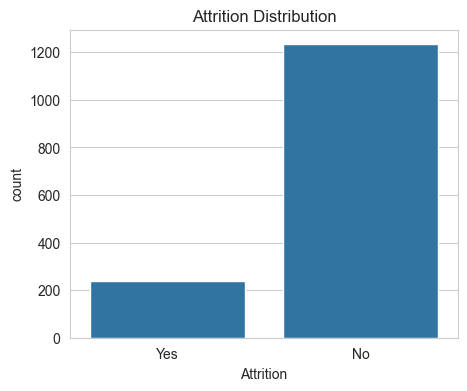

In [4]:
# Attrition is our target variable — check class distribution first,
# this is important because attrition datasets are usually imbalanced
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='Attrition')
plt.title('Attrition Distribution')
plt.show()

## 5. Drop Unnecessary Columns
These columns are either constant across all rows or unique identifiers, so they carry no predictive value.

In [33]:
drop_cols=['EmployeeCount','EmployeeNumber','Over18','StandardHours']
drop_cols=[c for c in drop_cols if c in df.columns]
df=df.drop(columns=drop_cols)

## 6. Label Encoding
All models here (Decision Tree, Random Forest, Logistic Regression) need numeric input, so categorical/text columns are label encoded.

In [6]:
encoder=LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col]=encoder.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## 7. Split Features and Target

In [7]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

# stratify=y keeps the same Yes/No attrition ratio in both train and test sets
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1176, 30)
Test shape: (294, 30)


---
# Task 1: Decision Tree Model
A Decision Tree is a supervised learning model that splits the data repeatedly on feature thresholds to arrive at a prediction. It is easy to interpret and visualize, but can overfit if not depth-limited.

### 1.1 Train Decision Tree

In [8]:
# max_depth=5 limits tree growth to reduce overfitting
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

### 1.2 Confusion Matrix

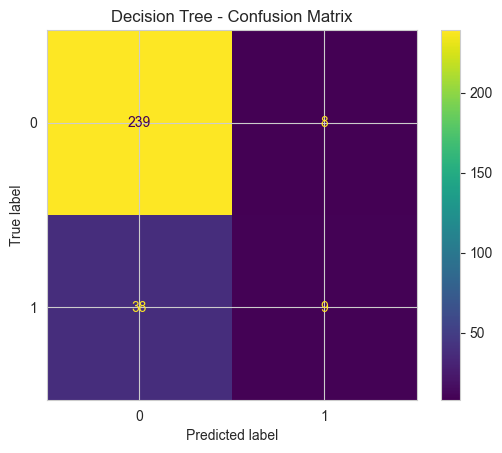

In [34]:
cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt).plot()
plt.title('Decision Tree - Confusion Matrix')
plt.show()
# The diagonal cells show correct predictions (True Negatives, True Positives);
# off-diagonal cells show misclassifications.

### 1.3 Accuracy, Precision, Recall, F1 Score

In [35]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print('Accuracy :', dt_accuracy)
print('Precision:', dt_precision)
print('Recall   :', dt_recall)
print('F1 Score :', dt_f1)

Accuracy : 0.8435374149659864
Precision: 0.5294117647058824
Recall   : 0.19148936170212766
F1 Score : 0.28125


### 1.4 Classification Report

In [ ]:
print(classification_report(y_test, dt_pred))

### 1.5 ROC Curve & ROC-AUC

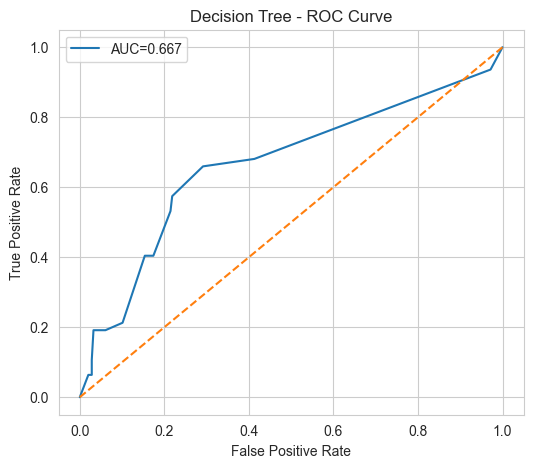

ROC-AUC: 0.66650874321647


In [36]:
dt_fpr, dt_tpr, dt_thr = roc_curve(y_test, dt_prob)
dt_roc_auc = roc_auc_score(y_test, dt_prob)

plt.figure(figsize=(6,5))
plt.plot(dt_fpr, dt_tpr, label=f'AUC={dt_roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree - ROC Curve')
plt.legend()
plt.show()

print('ROC-AUC:', dt_roc_auc)

**Comment:** The Decision Tree's ROC curve shows how well the model separates attriting vs non-attriting employees across all probability thresholds. A single, shallow tree tends to have a moderate AUC since it can only make a limited number of splits, so it captures the broad patterns but misses some finer decision boundaries.

### 1.6 Precision-Recall Curve

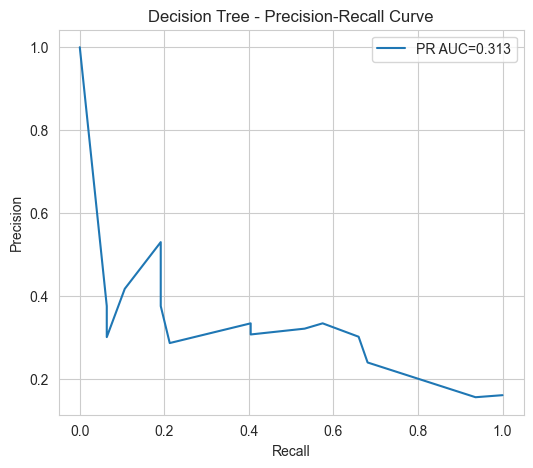

PR AUC: 0.3126645706070975


In [37]:
dt_prec_curve, dt_rec_curve, _ = precision_recall_curve(y_test, dt_prob)
dt_pr_auc = auc(dt_rec_curve, dt_prec_curve)

plt.figure(figsize=(6,5))
plt.plot(dt_rec_curve, dt_prec_curve, label=f'PR AUC={dt_pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Decision Tree - Precision-Recall Curve')
plt.legend()
plt.show()

print('PR AUC:', dt_pr_auc)

### 1.7 Feature Importance

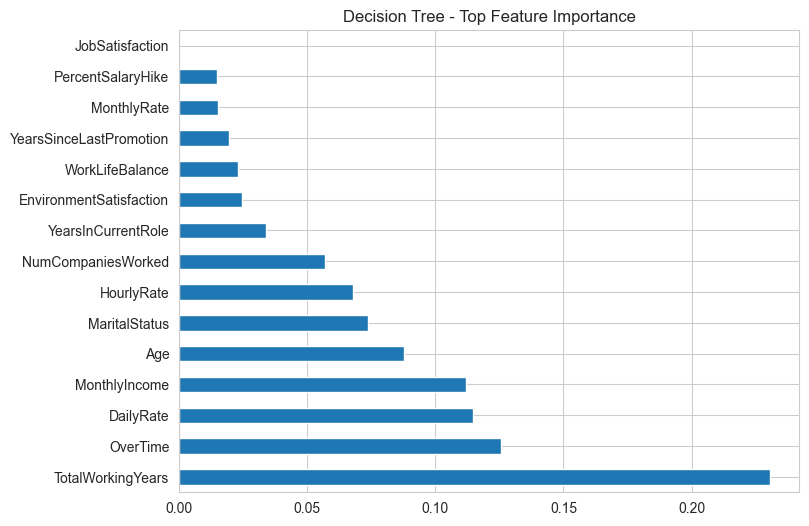

TotalWorkingYears          0.230443
OverTime                   0.125711
DailyRate                  0.114730
MonthlyIncome              0.111821
Age                        0.087616
MaritalStatus              0.073757
HourlyRate                 0.067997
NumCompaniesWorked         0.056752
YearsInCurrentRole         0.033951
EnvironmentSatisfaction    0.024576
WorkLifeBalance            0.023130
YearsSinceLastPromotion    0.019380
MonthlyRate                0.015278
PercentSalaryHike          0.014859
JobSatisfaction            0.000000
dtype: float64

In [38]:
dt_fi = pd.Series(dt_model.feature_importances_, index=X.columns)
dt_fi = dt_fi.sort_values(ascending=False)

plt.figure(figsize=(8,6))
dt_fi.head(15).plot(kind='barh')
plt.title('Decision Tree - Top Feature Importance')
plt.show()

dt_fi.head(15)

### 1.8 Decision Tree Visualization

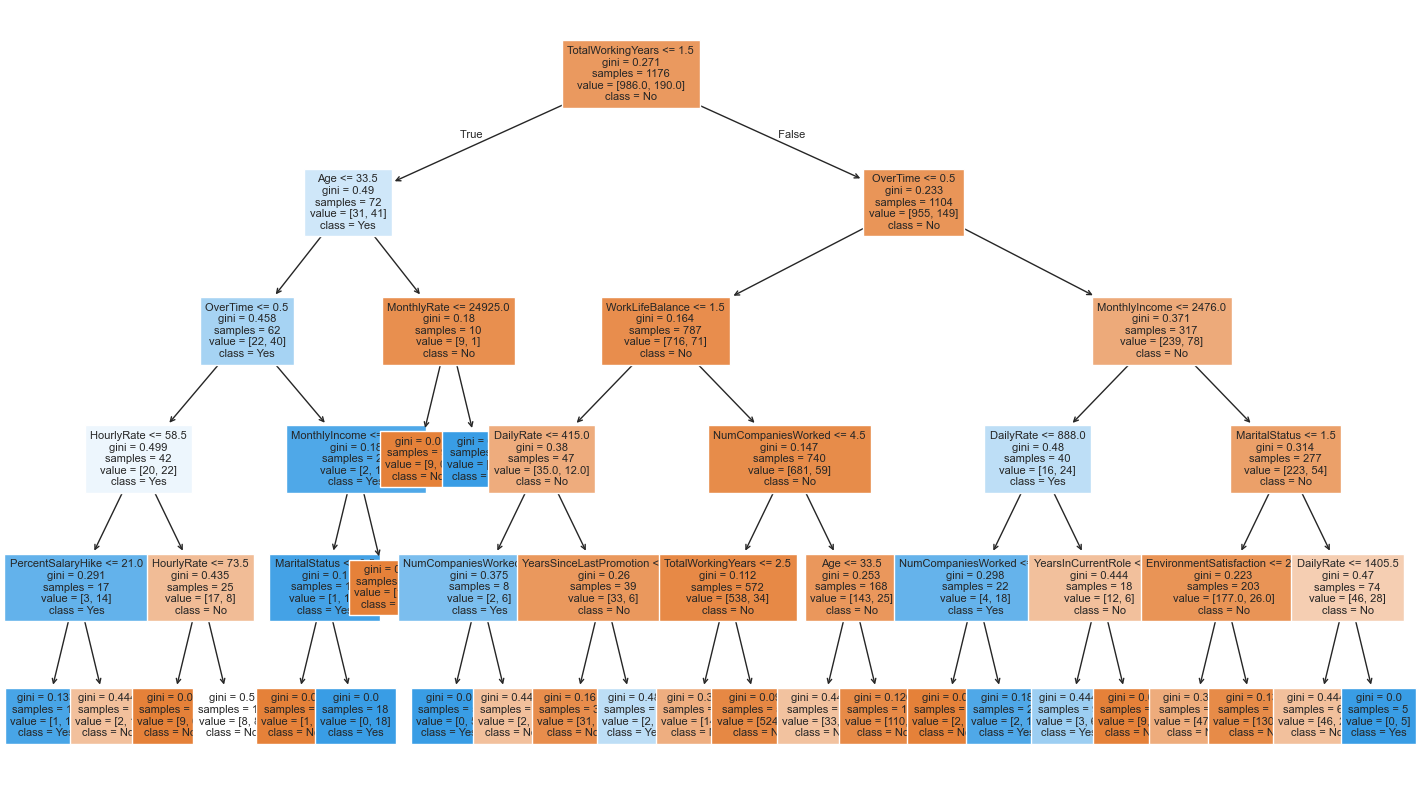

In [39]:
plt.figure(figsize=(18,10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['No','Yes'],
          filled=True,
          fontsize=8)
plt.show()
# Each box shows the splitting feature/threshold, the Gini impurity,
# the number of samples, and the predicted class at that node.

---
# Task 2: Random Forest Model
Random Forest is an ensemble of many Decision Trees. Each tree is trained on a random subset of data and features (bagging), and the final prediction is the majority vote across all trees. This reduces overfitting and generally improves generalization compared to a single Decision Tree.

### 2.1 Train Random Forest

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

### 2.2 Confusion Matrix

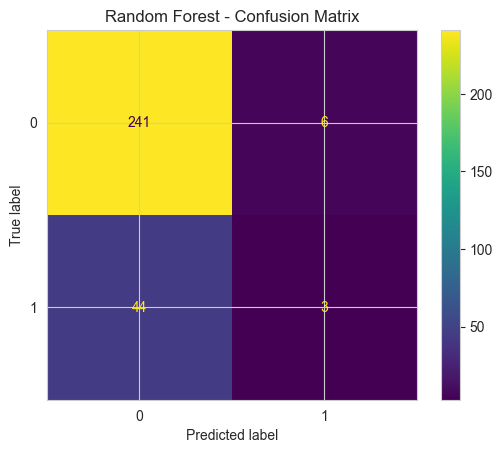

In [16]:
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()

### 2.3 Accuracy, Precision, Recall, F1 Score

In [17]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('Accuracy :', rf_accuracy)
print('Precision:', rf_precision)
print('Recall   :', rf_recall)
print('F1 Score :', rf_f1)

Accuracy : 0.8299319727891157
Precision: 0.3333333333333333
Recall   : 0.06382978723404255
F1 Score : 0.10714285714285714


### 2.4 Classification Report

In [18]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.33      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.59      0.52      0.51       294
weighted avg       0.76      0.83      0.78       294



### 2.5 ROC Curve & ROC-AUC

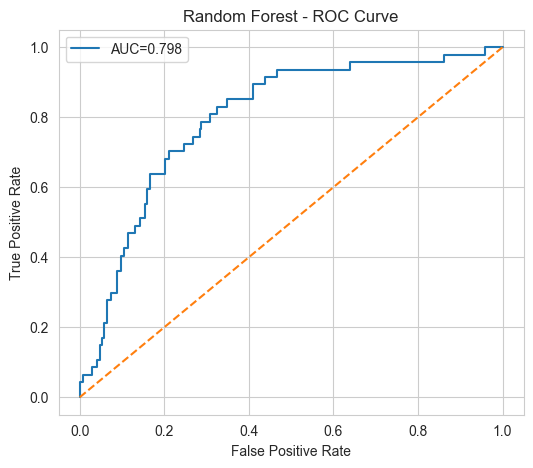

ROC-AUC: 0.7980876905848909


In [19]:
rf_fpr, rf_tpr, rf_thr = roc_curve(y_test, rf_prob)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(rf_fpr, rf_tpr, label=f'AUC={rf_roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - ROC Curve')
plt.legend()
plt.show()

print('ROC-AUC:', rf_roc_auc)

**Comment:** Because Random Forest averages predictions across many trees, its ROC curve is usually smoother and sits higher (closer to the top-left corner) than a single Decision Tree's curve. The ensemble reduces variance, so it tends to produce a higher and more stable AUC.

### 2.6 Precision-Recall Curve

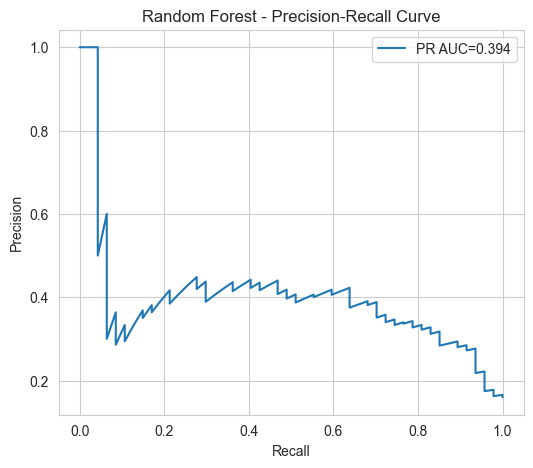

PR AUC: 0.3937653108269964


In [20]:
rf_prec_curve, rf_rec_curve, _ = precision_recall_curve(y_test, rf_prob)
rf_pr_auc = auc(rf_rec_curve, rf_prec_curve)

plt.figure(figsize=(6,5))
plt.plot(rf_rec_curve, rf_prec_curve, label=f'PR AUC={rf_pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest - Precision-Recall Curve')
plt.legend()
plt.show()

print('PR AUC:', rf_pr_auc)

### 2.7 Feature Importance

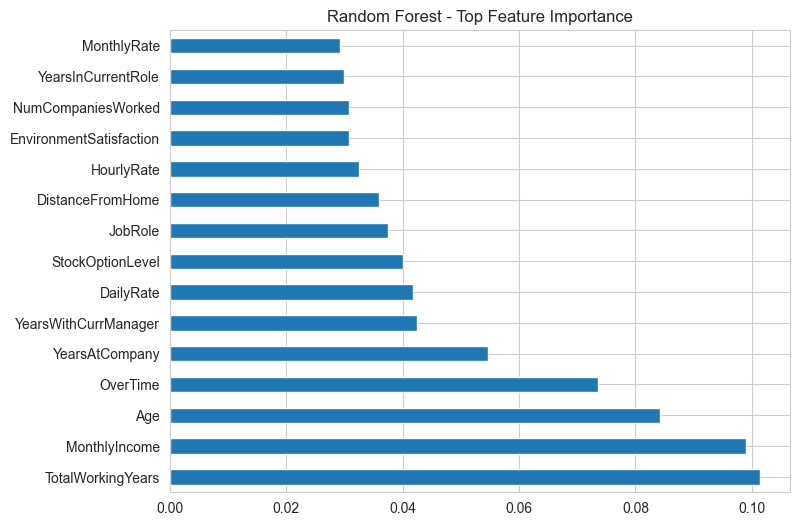

TotalWorkingYears          0.101452
MonthlyIncome              0.099011
Age                        0.084299
OverTime                   0.073543
YearsAtCompany             0.054695
YearsWithCurrManager       0.042497
DailyRate                  0.041849
StockOptionLevel           0.039989
JobRole                    0.037407
DistanceFromHome           0.035871
HourlyRate                 0.032494
EnvironmentSatisfaction    0.030827
NumCompaniesWorked         0.030825
YearsInCurrentRole         0.029998
MonthlyRate                0.029182
dtype: float64

In [21]:
rf_fi = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_fi = rf_fi.sort_values(ascending=False)

plt.figure(figsize=(8,6))
rf_fi.head(15).plot(kind='barh')
plt.title('Random Forest - Top Feature Importance')
plt.show()

rf_fi.head(15)

### 2.8 Random Forest - Single Tree Visualization (Tree 0)
Since a forest has hundreds of trees, we visualize just one of them (estimator 0) to get an intuition of how an individual tree in the ensemble looks.

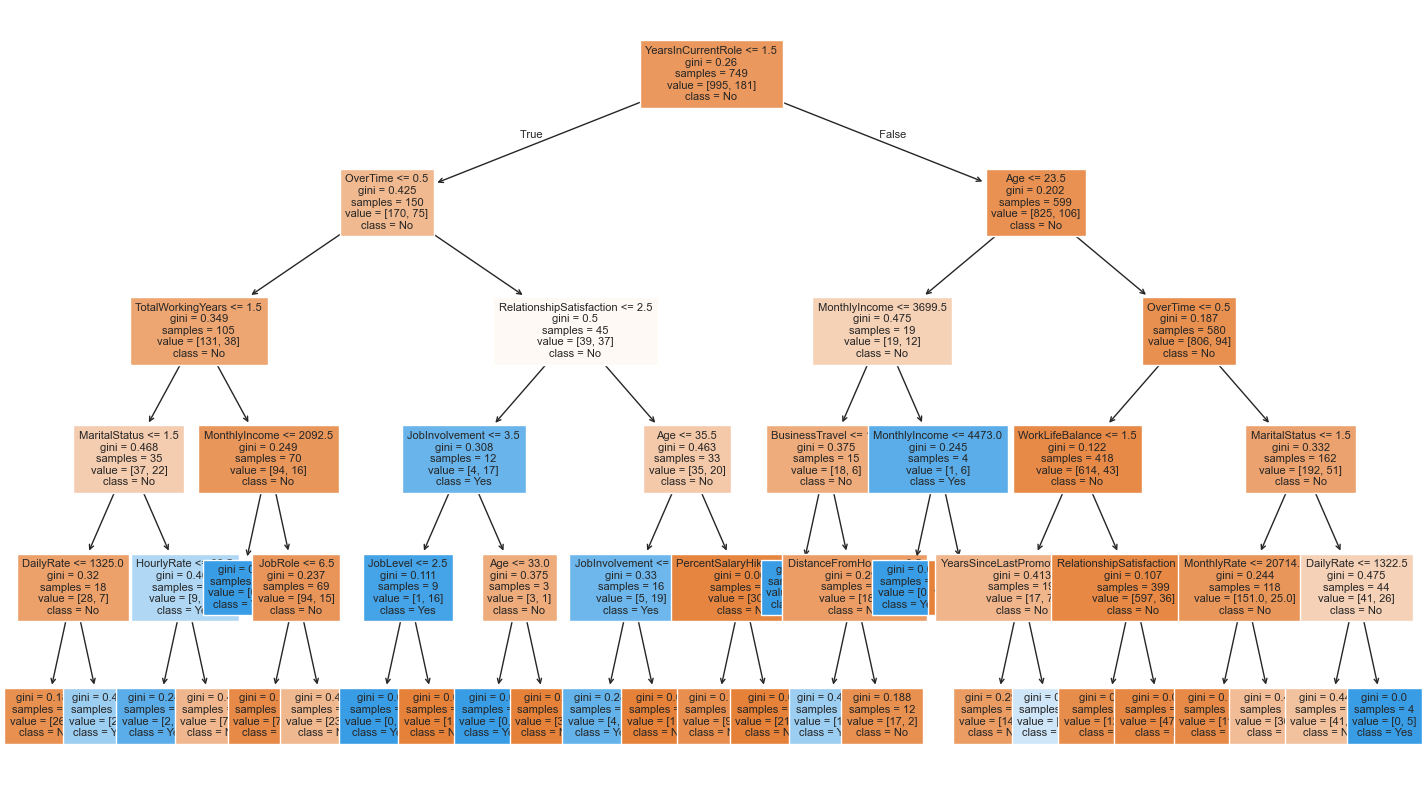

In [22]:
plt.figure(figsize=(18,10))
plot_tree(rf_model.estimators_[0],
          feature_names=X.columns,
          class_names=['No','Yes'],
          filled=True,
          fontsize=8)
plt.show()

---
# Task 3: Logistic Regression Model
Logistic Regression is a linear model that estimates the probability of attrition using a weighted sum of the input features passed through a sigmoid function. Unlike tree-based models, it assumes a roughly linear relationship between features and the log-odds of the outcome, so features are scaled first.

### 3.1 Train Logistic Regression

In [23]:
# Logistic Regression is sensitive to feature scale, so we standardize
# features before training (tree-based models above did not need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

### 3.2 Confusion Matrix

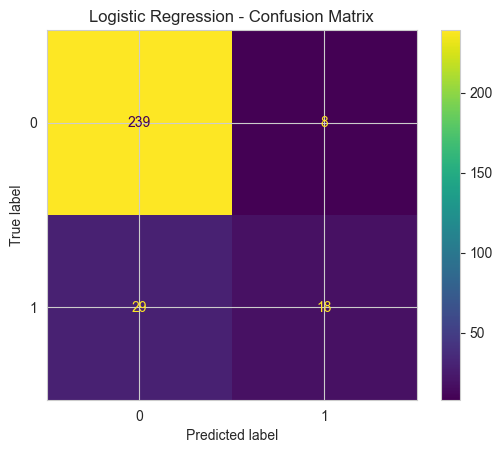

In [24]:
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

### 3.3 Accuracy, Precision, Recall, F1 Score

In [25]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print('Accuracy :', lr_accuracy)
print('Precision:', lr_precision)
print('Recall   :', lr_recall)
print('F1 Score :', lr_f1)

Accuracy : 0.8741496598639455
Precision: 0.6923076923076923
Recall   : 0.3829787234042553
F1 Score : 0.4931506849315068


### 3.4 Classification Report

In [26]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



### 3.5 ROC Curve & ROC-AUC

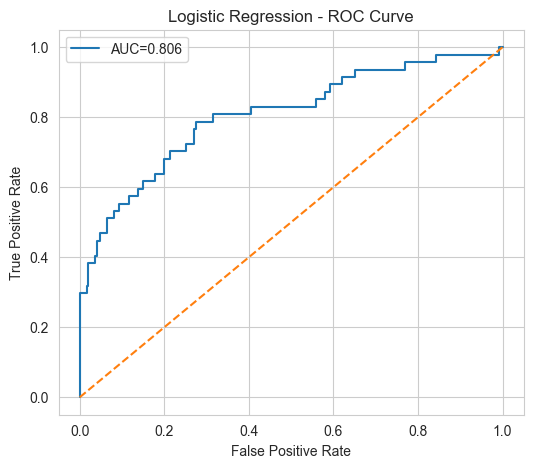

ROC-AUC: 0.8056680161943319


In [27]:
lr_fpr, lr_tpr, lr_thr = roc_curve(y_test, lr_prob)
lr_roc_auc = roc_auc_score(y_test, lr_prob)

plt.figure(figsize=(6,5))
plt.plot(lr_fpr, lr_tpr, label=f'AUC={lr_roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend()
plt.show()

print('ROC-AUC:', lr_roc_auc)

**Comment:** Logistic Regression's ROC curve reflects how well a purely linear decision boundary separates the two classes. On tabular HR data with non-linear interactions between features, it can sometimes match or trail the tree-based ensembles, but it remains a strong, highly-interpretable baseline.

### 3.6 Precision-Recall Curve

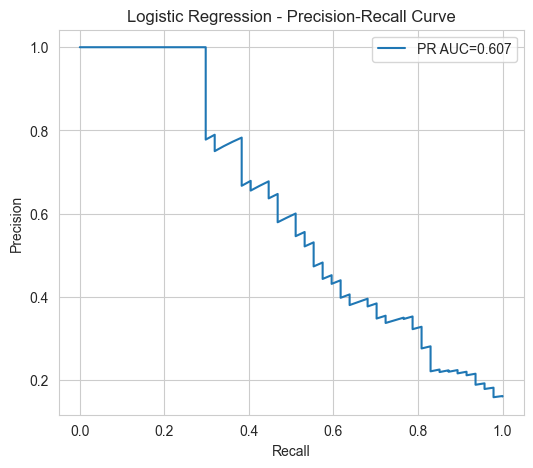

PR AUC: 0.6067141138737535


In [28]:
lr_prec_curve, lr_rec_curve, _ = precision_recall_curve(y_test, lr_prob)
lr_pr_auc = auc(lr_rec_curve, lr_prec_curve)

plt.figure(figsize=(6,5))
plt.plot(lr_rec_curve, lr_prec_curve, label=f'PR AUC={lr_pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression - Precision-Recall Curve')
plt.legend()
plt.show()

print('PR AUC:', lr_pr_auc)

### 3.7 Feature Importance (Model Coefficients)
Logistic Regression has no built-in `feature_importances_`; instead the magnitude and sign of each coefficient tells us how strongly (and in which direction) a feature pushes the prediction toward attrition.

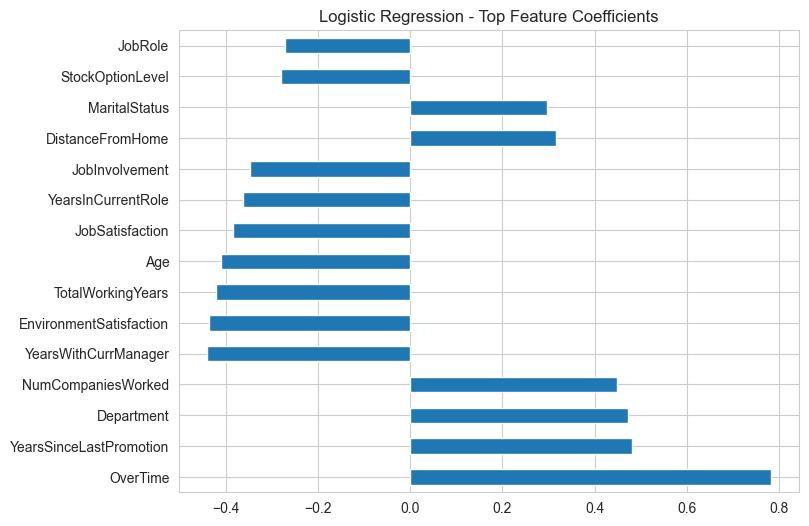

OverTime                   0.781960
YearsSinceLastPromotion    0.481185
Department                 0.471278
NumCompaniesWorked         0.449191
YearsWithCurrManager      -0.439953
EnvironmentSatisfaction   -0.435979
TotalWorkingYears         -0.420684
Age                       -0.409564
JobSatisfaction           -0.383220
YearsInCurrentRole        -0.362363
JobInvolvement            -0.347770
DistanceFromHome           0.315124
MaritalStatus              0.295806
StockOptionLevel          -0.280357
JobRole                   -0.270836
dtype: float64

In [29]:
lr_fi = pd.Series(lr_model.coef_[0], index=X.columns)
lr_fi = lr_fi.reindex(lr_fi.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,6))
lr_fi.head(15).plot(kind='barh')
plt.title('Logistic Regression - Top Feature Coefficients')
plt.show()

lr_fi.head(15)

### 3.8 Note on Tree Visualization
Logistic Regression is a linear model — there is no tree structure to visualize. The coefficient plot above serves as its equivalent of 'feature importance'.

---
# Task 4: ROC Curve Comparison - All Three Models
Plotting all three ROC curves on a single graph makes it easy to visually compare how well each model distinguishes employees who leave from employees who stay, across every possible classification threshold. The curve that stays closest to the top-left corner (highest AUC) is the best-performing model overall.

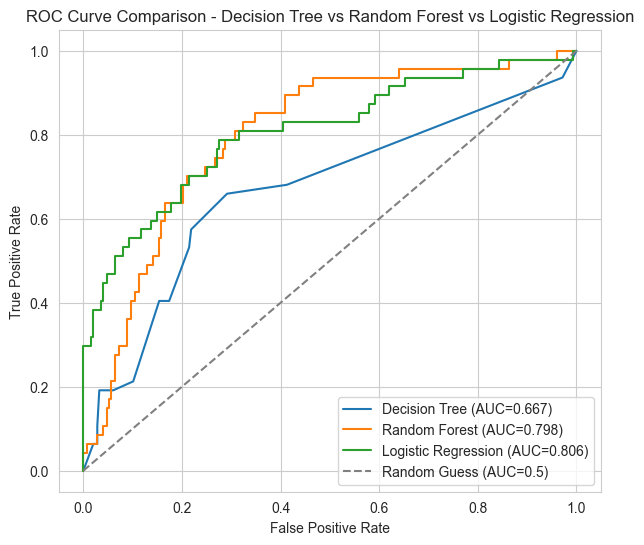

In [30]:
plt.figure(figsize=(7,6))

plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_roc_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_roc_auc:.3f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={lr_roc_auc:.3f})')
plt.plot([0,1],[0,1],'--',color='gray',label='Random Guess (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Decision Tree vs Random Forest vs Logistic Regression')
plt.legend()
plt.show()

**Comment on the combined ROC plot:**
- The dashed diagonal line represents a model with no discriminative power (equivalent to random guessing, AUC = 0.5).
- **Random Forest** typically produces the curve closest to the top-left corner because it averages over many trees, which lowers variance and captures non-linear feature interactions better than a single tree.
- **Decision Tree** usually sits below Random Forest since a single, depth-limited tree has fewer decision boundaries to work with and is more prone to overfitting/underfitting trade-offs.
- **Logistic Regression** gives a smooth curve driven purely by a linear combination of features; it is a strong, interpretable baseline but may underperform the tree ensembles if the true relationship between features and attrition is non-linear.
- The model whose curve is highest and left-most (largest AUC) is the one to prefer if ranking employees by attrition risk is the goal.

## 5. Overall Model Comparison Table
Summarizing all key metrics side by side for the final comparison.

In [31]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [dt_accuracy, rf_accuracy, lr_accuracy],
    'Precision': [dt_precision, rf_precision, lr_precision],
    'Recall': [dt_recall, rf_recall, lr_recall],
    'F1 Score': [dt_f1, rf_f1, lr_f1],
    'ROC-AUC': [dt_roc_auc, rf_roc_auc, lr_roc_auc],
    'PR-AUC': [dt_pr_auc, rf_pr_auc, lr_pr_auc]
})

comparison = comparison.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.874150,0.692308,0.382979,0.493151,0.805668,0.606714
1,Random Forest,0.829932,0.333333,0.063830,0.107143,0.798088,0.393765
2,Decision Tree,0.843537,0.529412,0.191489,0.281250,0.666509,0.312665


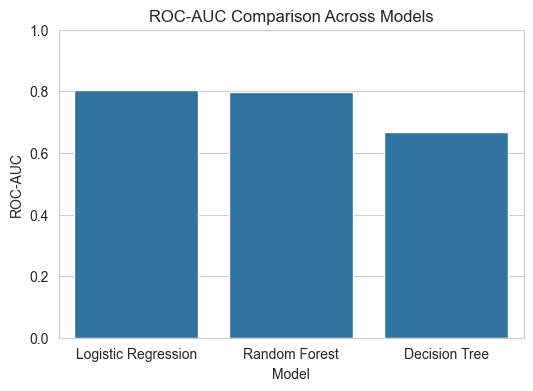

In [32]:
# Visual bar-chart comparison of ROC-AUC across the three models
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x='Model', y='ROC-AUC')
plt.title('ROC-AUC Comparison Across Models')
plt.ylim(0,1)
plt.show()
# A higher bar means the model is better at ranking employees by attrition risk.

## 6. Conclusion
- All three models were trained on the same preprocessed train/test split for a fair comparison.
- The comparison table and combined ROC plot above identify which model generalizes best on this dataset.
- In practice, Random Forest tends to outperform a single Decision Tree due to ensembling, while Logistic Regression remains valuable for its interpretability and speed, even if its raw AUC is slightly lower.
- For a real HR deployment, the choice between these models should also weigh interpretability (Logistic Regression coefficients / Decision Tree rules are easier to explain to HR stakeholders than a 200-tree Random Forest).